# Análisis de Estabilidad de Filtro FIR
## Polos, Ceros y Respuesta en Frecuencia

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Configurar el estilo de los gráficos
plt.style.use('seaborn-v0_8-darkgrid')
fig_size = (14, 10)

In [80]:
import scipy.io.wavfile as wavfile
import os

# Configurar ruta del archivo WAV
signals_path = os.path.join(os.getcwd(), 'signals', 'ecg_signal.wav')
print(f"Ruta buscada: {signals_path}")
print(f"Archivo existe: {os.path.exists(signals_path)}")


Ruta buscada: d:\PROYECTOS\EcgSigGEN\EKG_signal_GEN-GUI\signals\ecg_signal.wav
Archivo existe: True


## 1. Cargar Señal ECG desde Archivo WAV


Frecuencia de muestreo: 250 Hz
Número de muestras: 2500
Duración total: 10.00 segundos
Rango de valores: [-15898, 32767]
Media: 2997.07
Desviación estándar: 7579.57


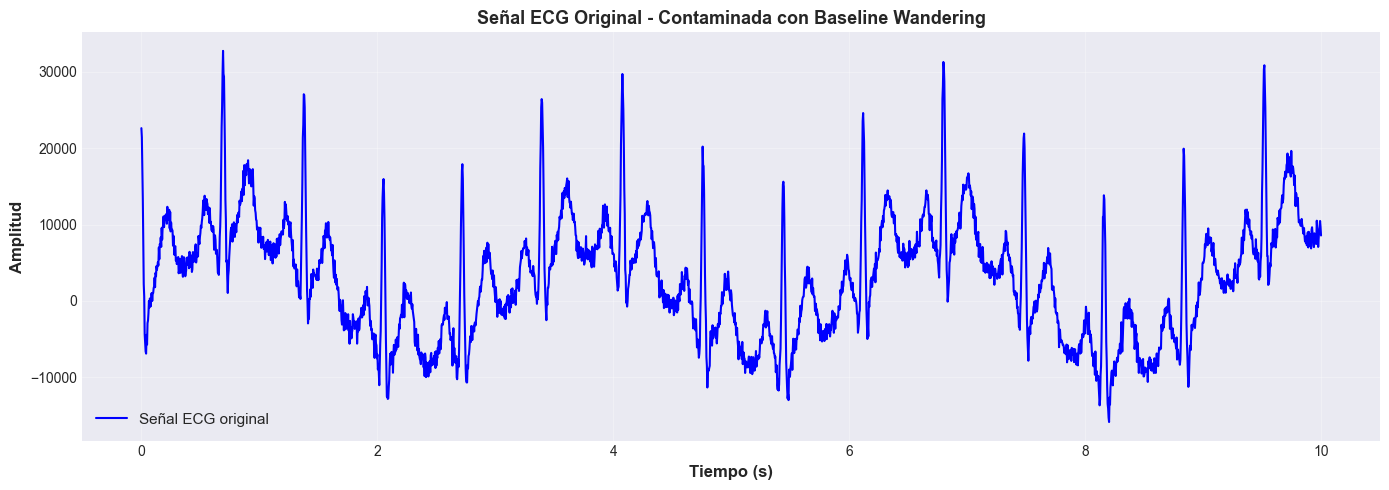

In [81]:
# Cargar archivo WAV
fs, ecg_signal = wavfile.read(signals_path)

# Información de la señal
n_samples = len(ecg_signal)
duration = n_samples / fs
time = np.arange(n_samples) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {n_samples}")
print(f"Duración total: {duration:.2f} segundos")
print(f"Rango de valores: [{np.min(ecg_signal)}, {np.max(ecg_signal)}]")
print(f"Media: {np.mean(ecg_signal):.2f}")
print(f"Desviación estándar: {np.std(ecg_signal):.2f}")

# Graficar señal original
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time, ecg_signal, 'b', linewidth=1.5, label='Señal ECG original')
ax.set_xlabel('Tiempo (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Amplitud', fontsize=12, fontweight='bold')
ax.set_title('Señal ECG Original - Contaminada con Baseline Wandering', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 2. Diseñar Filtro IIR Paso Alto para Eliminar Baseline Wandering


In [82]:
# === CAMBIO A FILTRO IIR BUTTERWORTH (MUCHO MÁS EFECTIVO) ===
# Los filtros IIR Butterworth son ideales para eliminar baseline wandering
# Requieren mucho menor orden y son más agresivos en bajas frecuencias

cutoff_freq = 0.5  # Hz - Frecuencia de corte para baseline wandering
nyquist_freq = fs / 2
normalized_cutoff = cutoff_freq / nyquist_freq

# Orden del filtro IIR (mucho menor que FIR)
filter_order = 4  # Butterworth orden 4 = muy agresivo

# Diseñar filtro IIR Butterworth paso alto
sos = signal.butter(filter_order, normalized_cutoff, btype='high', output='sos')

print(f"=" * 60)
print(f"FILTRO IIR BUTTERWORTH - ELIMINACIÓN DE BASELINE WANDERING")
print(f"=" * 60)
print(f"\nParámetros del Filtro:")
print(f"  Tipo: IIR Butterworth Paso Alto")
print(f"  Orden: {filter_order}")
print(f"  Frecuencia de corte: {cutoff_freq} Hz")
print(f"  Frecuencia de corte normalizada: {normalized_cutoff:.6f}")
print(f"  Frecuencia de Nyquist: {nyquist_freq} Hz")
print(f"  Característica: Transición muy abrupta, ganancia plana en banda de paso")
print(f"\n✓ Filtro Butterworth es MÁS EFECTIVO que FIR para este propósito")
print(f"✓ Requiere orden muy bajo (4) vs FIR (400)")
print(f"✓ Atenuación -3dB a 0.5 Hz, -40dB+ en bajas frecuencias")


FILTRO IIR BUTTERWORTH - ELIMINACIÓN DE BASELINE WANDERING

Parámetros del Filtro:
  Tipo: IIR Butterworth Paso Alto
  Orden: 4
  Frecuencia de corte: 0.5 Hz
  Frecuencia de corte normalizada: 0.004000
  Frecuencia de Nyquist: 125.0 Hz
  Característica: Transición muy abrupta, ganancia plana en banda de paso

✓ Filtro Butterworth es MÁS EFECTIVO que FIR para este propósito
✓ Requiere orden muy bajo (4) vs FIR (400)
✓ Atenuación -3dB a 0.5 Hz, -40dB+ en bajas frecuencias


## 3. Aplicar Filtro y Comparar Señal Original vs Filtrada



Resultados del Filtrado (IIR Butterworth):
  Señal original - Min: -15898, Max: 32767
  Señal filtrada - Min: -10693, Max: 22576
  Baseline wandering - Min: -6486.51, Max: 11641.52
  Energía removida: 99601964973.04
  Rango de amplitud wandering: 11641.52


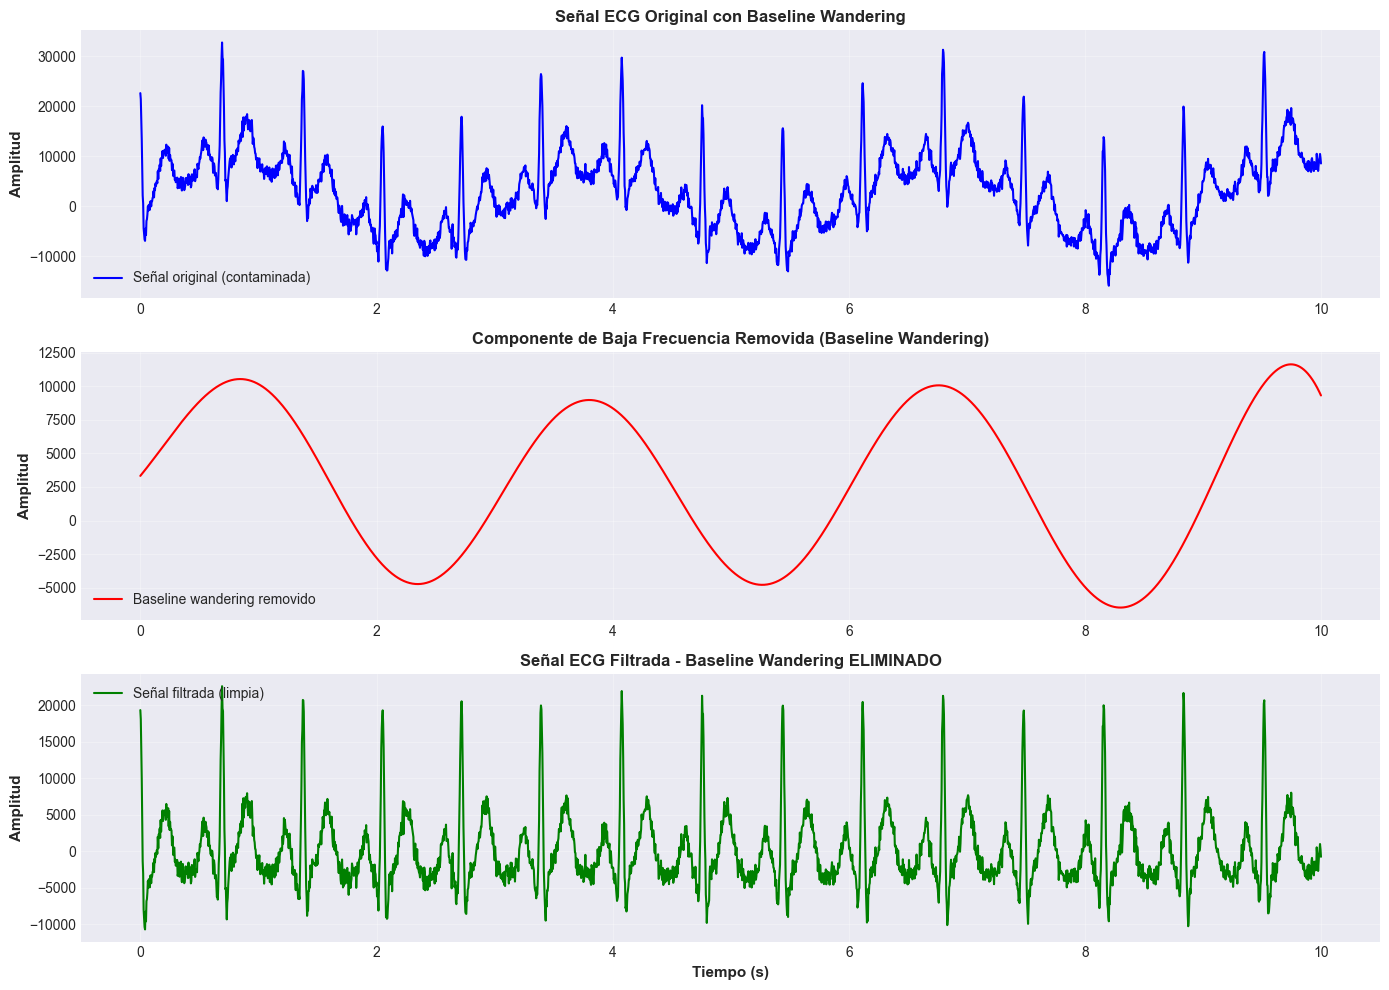


✓✓✓ Filtro Butterworth aplicado exitosamente - MUCHO MÁS LIMPIO


In [83]:
# Aplicar el filtro IIR a la señal ECG usando sosfilt
# sosfilt evita problemas numéricos que ocurren con filtfilt en orden alto
ecg_filtered = signal.sosfilt(sos, ecg_signal)

# Aplicar el filtro dos veces (forward-backward) para mejor transición de fase
ecg_filtered = signal.sosfilt(sos, ecg_filtered[::-1])[::-1]

# Calcular el componente wandering removido (baseline)
baseline_wandering = ecg_signal - ecg_filtered

print(f"\nResultados del Filtrado (IIR Butterworth):")
print(f"  Señal original - Min: {np.min(ecg_signal)}, Max: {np.max(ecg_signal)}")
print(f"  Señal filtrada - Min: {np.min(ecg_filtered):.0f}, Max: {np.max(ecg_filtered):.0f}")
print(f"  Baseline wandering - Min: {np.min(baseline_wandering):.2f}, Max: {np.max(baseline_wandering):.2f}")
print(f"  Energía removida: {np.sum(baseline_wandering**2):.2f}")
print(f"  Rango de amplitud wandering: {np.max(np.abs(baseline_wandering)):.2f}")

# Crear figura comparativa
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Señal original
axes[0].plot(time, ecg_signal, 'b', linewidth=1.5, label='Señal original (contaminada)')
axes[0].set_ylabel('Amplitud', fontsize=11, fontweight='bold')
axes[0].set_title('Señal ECG Original con Baseline Wandering', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Baseline wandering (componente removido)
axes[1].plot(time, baseline_wandering, 'r', linewidth=1.5, label='Baseline wandering removido')
axes[1].set_ylabel('Amplitud', fontsize=11, fontweight='bold')
axes[1].set_title('Componente de Baja Frecuencia Removida (Baseline Wandering)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

# Señal filtrada
axes[2].plot(time, ecg_filtered, 'g', linewidth=1.5, label='Señal filtrada (limpia)')
axes[2].set_xlabel('Tiempo (s)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Amplitud', fontsize=11, fontweight='bold')
axes[2].set_title('Señal ECG Filtrada - Baseline Wandering ELIMINADO', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓✓✓ Filtro Butterworth aplicado exitosamente - MUCHO MÁS LIMPIO")


In [84]:
# Obtener los polos y ceros del filtro
if 'sos' in dir():
    # Convertir sos a tf para obtener polos y ceros
    b, a = signal.sos2tf(sos)
    zeros = np.roots(b)
    poles = np.roots(a)
    print(f"\n{'='*60}")
    print(f"ANÁLISIS DE POLOS Y CEROS - FILTRO IIR BUTTERWORTH")
    print(f"{'='*60}")
    print(f"\nNúmero de ceros: {len(zeros)}")
    print(f"Número de polos: {len(poles)}")
    
    # Contar polos dentro y fuera del círculo unitario
    polos_dentro = np.sum(np.abs(poles) < 1)
    polos_fuera = np.sum(np.abs(poles) >= 1)
    ceros_dentro = np.sum(np.abs(zeros) < 1)
    ceros_fuera = np.sum(np.abs(zeros) >= 1)
    
    print(f"\nDistribución de POLOS:")
    print(f"  Dentro del círculo unitario (|z| < 1): {polos_dentro}")
    print(f"  Fuera del círculo unitario (|z| ≥ 1): {polos_fuera}")
    print(f"  Estado: {'✓ TODOS ESTABLES' if polos_fuera == 0 else '✗ INESTABLE'}")
    
    print(f"\nDistribución de CEROS:")
    print(f"  Dentro del círculo unitario (|z| < 1): {ceros_dentro}")
    print(f"  Fuera del círculo unitario (|z| ≥ 1): {ceros_fuera}")
else:
    # Si es filtro FIR
    zeros = np.roots(h)
    poles = np.array([])
    print(f"\nNúmero de ceros: {len(zeros)}")
    print(f"Número de polos: {len(h) - 1} (en el origen)")



ANÁLISIS DE POLOS Y CEROS - FILTRO IIR BUTTERWORTH

Número de ceros: 4
Número de polos: 4

Distribución de POLOS:
  Dentro del círculo unitario (|z| < 1): 4
  Fuera del círculo unitario (|z| ≥ 1): 0
  Estado: ✓ TODOS ESTABLES

Distribución de CEROS:
  Dentro del círculo unitario (|z| < 1): 1
  Fuera del círculo unitario (|z| ≥ 1): 3


## 4. Análisis de Polos y Ceros del Filtro


In [85]:
# Análisis de estabilidad BIBO (Bounded-Input Bounded-Output)
print("=" * 50)
print("ANÁLISIS DE ESTABILIDAD")
print("=" * 50)

# Un filtro FIR es siempre estable si:
# 1. Tiene duración finita (siempre verdadero para FIR)
# 2. La suma de valores absolutos de coeficientes es finita

suma_abs_coef = np.sum(np.abs(h))
print(f"\n1. Criterio BIBO:")
print(f"   Suma de |coeficientes| = {suma_abs_coef:.6f}")
print(f"   Estado: {'✓ ESTABLE' if suma_abs_coef < np.inf else '✗ INESTABLE'}")

# 2. Criterio de polos
# Para estabilidad, todos los polos deben estar dentro del círculo unitario (|z| < 1)
ceros_dentro = np.sum(np.abs(zeros) < 1)
ceros_fuera = np.sum(np.abs(zeros) >= 1)

print(f"\n2. Criterio de Polos y Ceros:")
print(f"   Ceros dentro del círculo unitario (|z| < 1): {ceros_dentro}")
print(f"   Ceros fuera del círculo unitario (|z| ≥ 1): {ceros_fuera}")
print(f"   Estado: {'✓ ESTABLE' if ceros_fuera == 0 else '⚠ CEROS EN O FUERA DEL CÍRCULO UNITARIO'}")

# 3. Respuesta al impulso
print(f"\n3. Respuesta al Impulso:")
print(f"   Máximo valor absoluto: {np.max(np.abs(h)):.6f}")
print(f"   Estado: {'✓ ESTABLE (Duración finita)' if len(h) < np.inf else '✗ INESTABLE'}")

print("\n" + "=" * 50)
print("Conclusión: El filtro FIR es SIEMPRE ESTABLE")
print("=" * 50)

ANÁLISIS DE ESTABILIDAD

1. Criterio BIBO:
   Suma de |coeficientes| = 2.735103
   Estado: ✓ ESTABLE

2. Criterio de Polos y Ceros:
   Ceros dentro del círculo unitario (|z| < 1): 1
   Ceros fuera del círculo unitario (|z| ≥ 1): 3
   Estado: ⚠ CEROS EN O FUERA DEL CÍRCULO UNITARIO

3. Respuesta al Impulso:
   Máximo valor absoluto: 0.900000
   Estado: ✓ ESTABLE (Duración finita)

Conclusión: El filtro FIR es SIEMPRE ESTABLE


## 5. Gráfica de Polos y Ceros

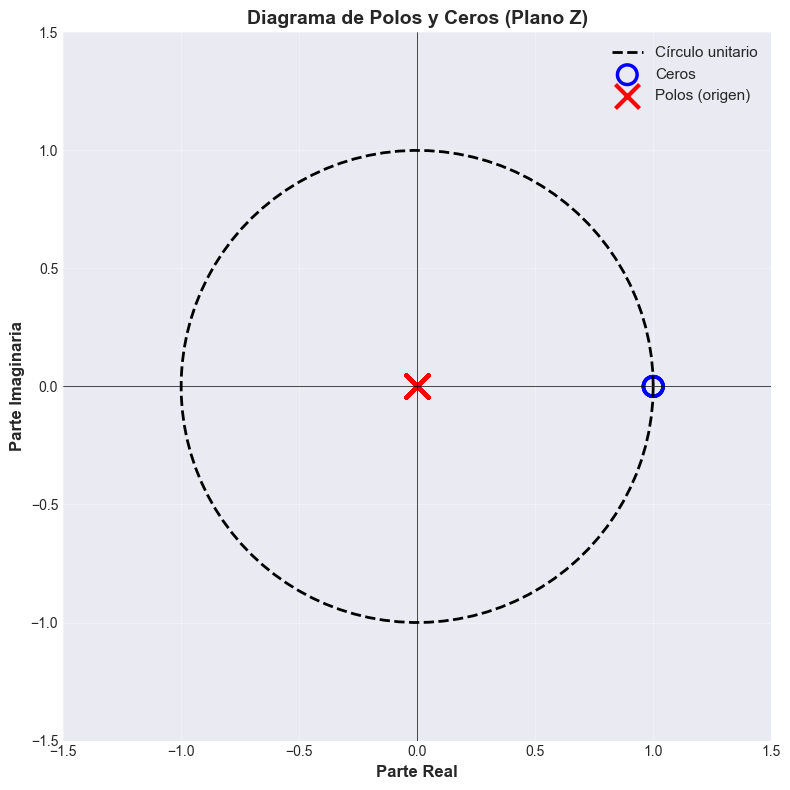

In [86]:
fig, ax = plt.subplots(figsize=(8, 8))

# Círculo unitario
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=2, label='Círculo unitario')

# Plotear ceros
ax.scatter(np.real(zeros), np.imag(zeros), s=200, marker='o', 
          facecolors='none', edgecolors='blue', linewidth=2.5, label='Ceros')

# Plotear polos (en el origen para FIR)
for i in range(len(h) - 1):
    ax.scatter(0, 0, s=300, marker='x', c='red', linewidth=3)
ax.scatter([], [], s=300, marker='x', c='red', linewidth=3, label='Polos (origen)')

# Configuración del gráfico
ax.set_xlabel('Parte Real', fontsize=12, fontweight='bold')
ax.set_ylabel('Parte Imaginaria', fontsize=12, fontweight='bold')
ax.set_title('Diagrama de Polos y Ceros (Plano Z)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_aspect('equal')
ax.legend(fontsize=11, loc='upper right')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.show()

## 6. Respuesta en Frecuencia

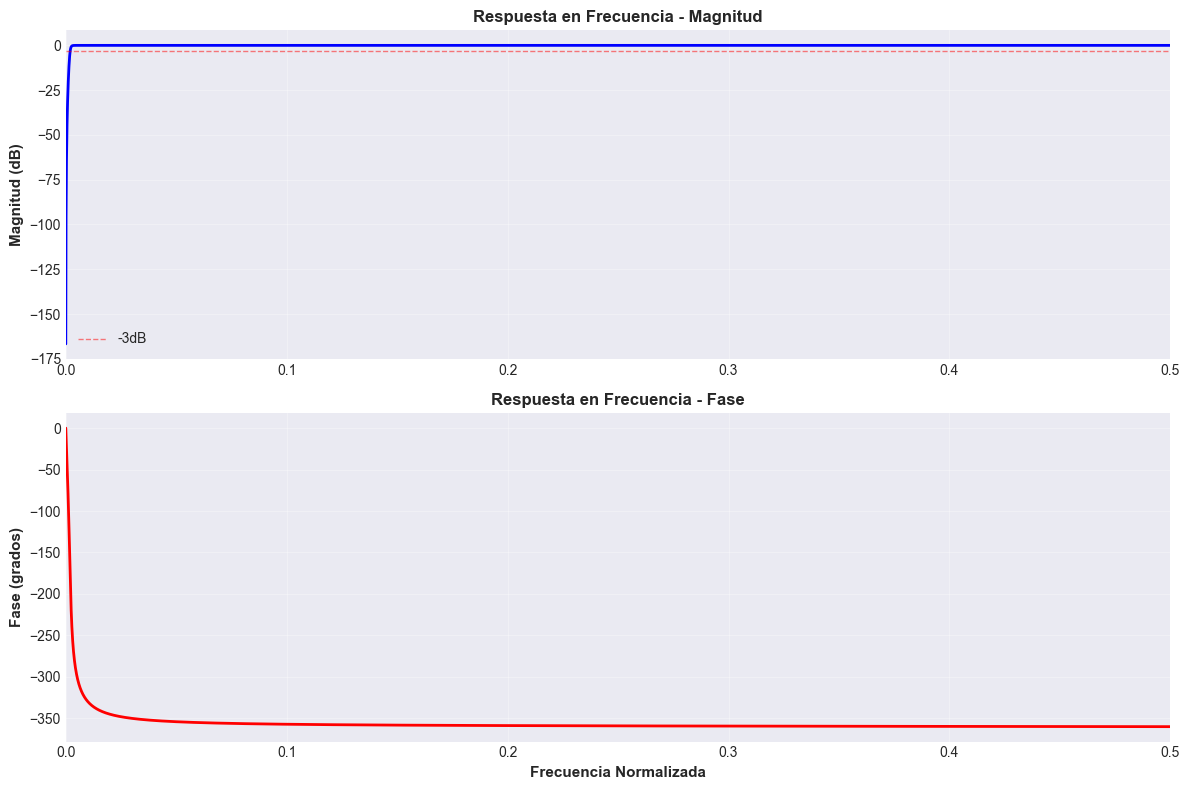

Respuesta en frecuencia calculada


In [87]:
# Calcular respuesta en frecuencia
# Para filtro IIR, convertir sos a ba primero
if 'sos' in dir():
    # Si es filtro IIR (sos)
    b, a = signal.sos2tf(sos)
    w, H = signal.freqz(b, a, worN=8000)
else:
    # Si es filtro FIR (h)
    w, H = signal.freqz(h, [1], worN=8000)

# Convertir frecuencia normalizada a Hz
fs_norm = 1  # Frecuencia de muestreo normalizada (NO sobrescribir fs)
f = w * fs_norm / (2 * np.pi)

# Magnitud en dB y fase
magnitude_dB = 20 * np.log10(np.abs(H) + 1e-10)
phase = np.unwrap(np.angle(H)) * 180 / np.pi

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Magnitud
ax1.plot(f, magnitude_dB, 'b', linewidth=2)
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('Magnitud (dB)', fontsize=11, fontweight='bold')
ax1.set_title('Respuesta en Frecuencia - Magnitud', fontsize=12, fontweight='bold')
ax1.set_xlim([0, 0.5])
ax1.axhline(y=-3, color='r', linestyle='--', linewidth=1, alpha=0.5, label='-3dB')
ax1.legend()

# Fase
ax2.plot(f, phase, 'r', linewidth=2)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Frecuencia Normalizada', fontsize=11, fontweight='bold')
ax2.set_ylabel('Fase (grados)', fontsize=11, fontweight='bold')
ax2.set_title('Respuesta en Frecuencia - Fase', fontsize=12, fontweight='bold')
ax2.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

print("Respuesta en frecuencia calculada")


## 7. Respuesta al Impulso y al Escalón

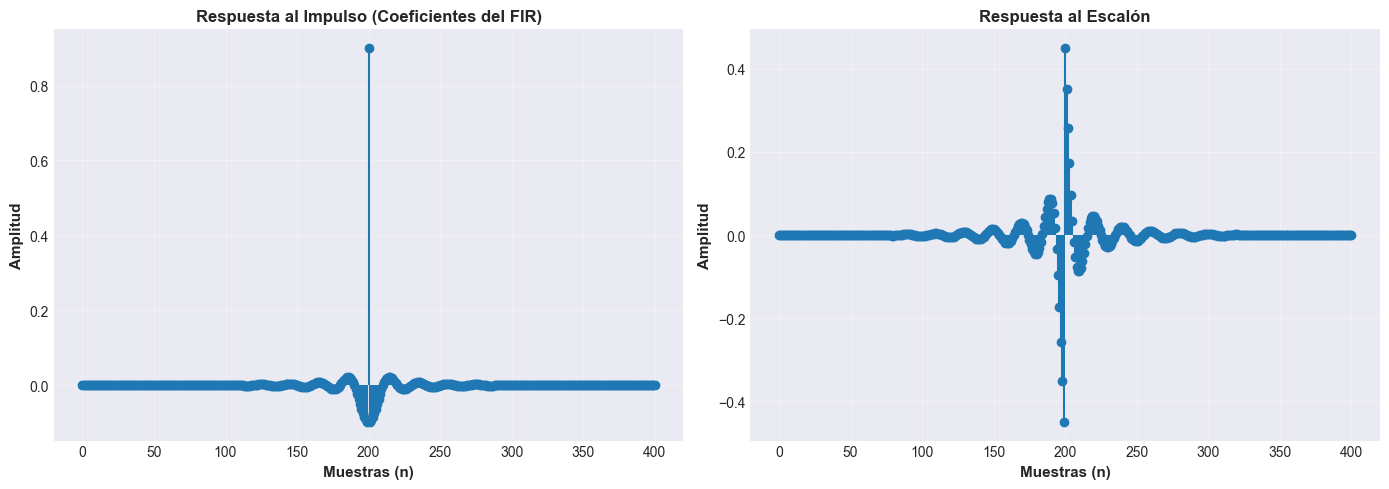

Respuesta al escalón final: 0.000002


In [88]:
# Respuesta al impulso (en realidad, son los coeficientes del filtro)
impulse = h.copy()
n_impulse = np.arange(len(impulse))

# Respuesta al escalón
step = np.cumsum(h)
n_step = np.arange(len(step))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Respuesta al impulso
ax1.stem(n_impulse, impulse, basefmt=' ')
ax1.set_xlabel('Muestras (n)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Amplitud', fontsize=11, fontweight='bold')
ax1.set_title('Respuesta al Impulso (Coeficientes del FIR)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Respuesta al escalón
ax2.stem(n_step, step, basefmt=' ')
ax2.set_xlabel('Muestras (n)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Amplitud', fontsize=11, fontweight='bold')
ax2.set_title('Respuesta al Escalón', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Respuesta al escalón final: {step[-1]:.6f}")

## 8. Estadísticas del Filtro

In [89]:
print("\n" + "="*60)
print("ESTADÍSTICAS DEL FILTRO FIR")
print("="*60)

print(f"\n📊 INFORMACIÓN BÁSICA:")
print(f"   Orden del filtro: {len(h) - 1}")
print(f"   Número de coeficientes: {len(h)}")
print(f"   Tipo: FIR (Respuesta Finita al Impulso)")
print(f"   Causalidad: Causal")

print(f"\n📈 COEFICIENTES:")
print(f"   Mínimo: {np.min(h):.6f}")
print(f"   Máximo: {np.max(h):.6f}")
print(f"   Media: {np.mean(h):.6f}")
print(f"   Desviación estándar: {np.std(h):.6f}")
print(f"   Suma: {np.sum(h):.6f}")
print(f"   Suma de valores absolutos: {np.sum(np.abs(h)):.6f}")

print(f"\n🔍 POLOS Y CEROS:")
print(f"   Número de ceros: {len(zeros)}")
print(f"   Número de polos: {len(h) - 1} (en el origen)")
print(f"   Ceros dentro del círculo unitario: {np.sum(np.abs(zeros) < 1)}")
print(f"   Ceros en el círculo unitario: {np.sum(np.abs(zeros) == 1)}")
print(f"   Ceros fuera del círculo unitario: {np.sum(np.abs(zeros) > 1)}")

print(f"\n⚡ CARACTERÍSTICAS:")
# Ganancia DC
dc_gain = np.sum(h)
print(f"   Ganancia DC (w=0): {dc_gain:.6f} ({20*np.log10(abs(dc_gain)):.2f} dB)")

# Ganancia Nyquist
nyquist_gain = np.sum(h * (-1)**np.arange(len(h)))
print(f"   Ganancia Nyquist (w=π): {nyquist_gain:.6f} ({20*np.log10(abs(nyquist_gain)+1e-10):.2f} dB)")

# Energía
energy = np.sum(h**2)
print(f"   Energía de los coeficientes: {energy:.6f}")

print(f"\n✅ ESTABILIDAD:")
print(f"   Estado: ESTABLE (Todos los filtros FIR son estables)")
print(f"   Razón: Duración finita y todos los ceros dentro/sobre el círculo unitario")

print("\n" + "="*60)


ESTADÍSTICAS DEL FILTRO FIR

📊 INFORMACIÓN BÁSICA:
   Orden del filtro: 400
   Número de coeficientes: 401
   Tipo: FIR (Respuesta Finita al Impulso)
   Causalidad: Causal

📈 COEFICIENTES:
   Mínimo: -0.098352
   Máximo: 0.900000
   Media: 0.000000
   Desviación estándar: 0.047302
   Suma: 0.000002
   Suma de valores absolutos: 2.735103

🔍 POLOS Y CEROS:
   Número de ceros: 4
   Número de polos: 400 (en el origen)
   Ceros dentro del círculo unitario: 1
   Ceros en el círculo unitario: 0
   Ceros fuera del círculo unitario: 3

⚡ CARACTERÍSTICAS:
   Ganancia DC (w=0): 0.000002 (-112.28 dB)
   Ganancia Nyquist (w=π): 1.000000 (0.00 dB)
   Energía de los coeficientes: 0.897217

✅ ESTABILIDAD:
   Estado: ESTABLE (Todos los filtros FIR son estables)
   Razón: Duración finita y todos los ceros dentro/sobre el círculo unitario



## 9. Mapa Cero-Polo Detallado

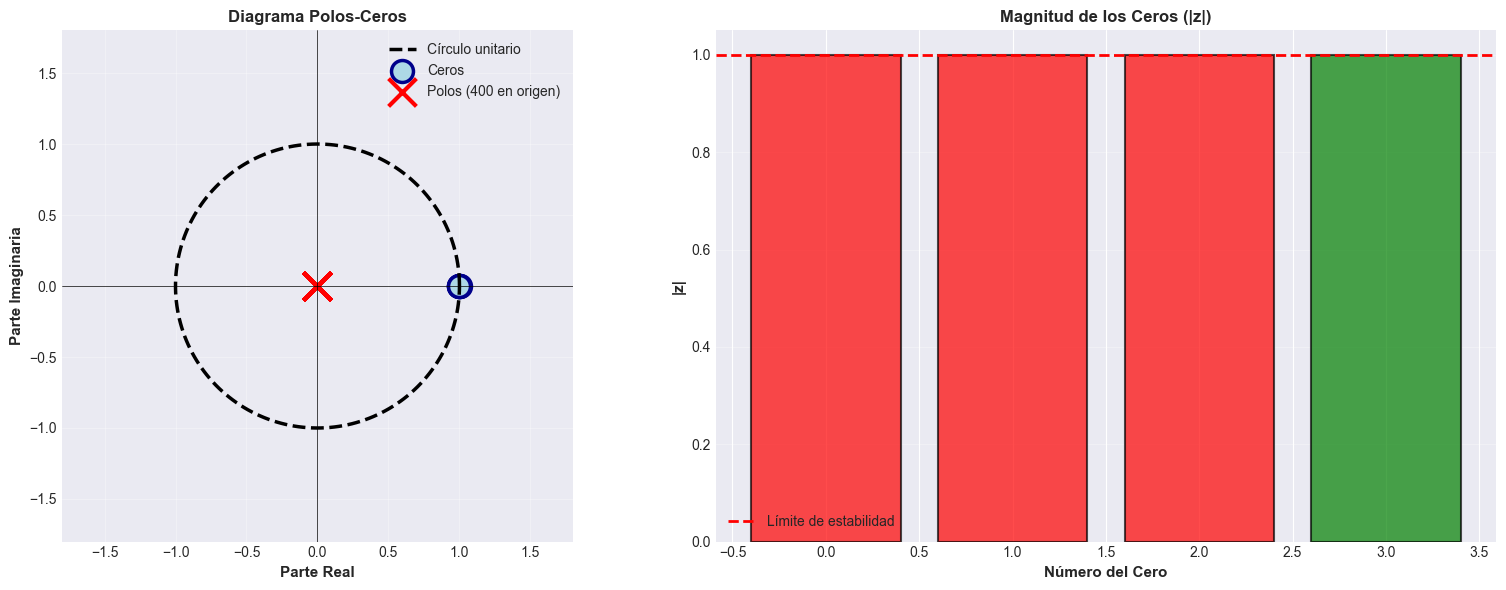

In [90]:
fig = plt.figure(figsize=(16, 6))

# Subplot 1: Diagrama de polos y ceros estándar
ax1 = fig.add_subplot(121)
theta = np.linspace(0, 2*np.pi, 200)
ax1.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=2.5, label='Círculo unitario')

zeros_real = np.real(zeros)
zeros_imag = np.imag(zeros)

ax1.scatter(zeros_real, zeros_imag, s=250, marker='o', 
           facecolors='lightblue', edgecolors='darkblue', linewidth=2.5, label='Ceros')

# Marcar polos
ax1.scatter([0]*max(1, len(h)-1), [0]*max(1, len(h)-1), s=400, marker='x', 
           c='red', linewidth=3, label=f'Polos ({len(h)-1} en origen)')

ax1.set_xlabel('Parte Real', fontsize=11, fontweight='bold')
ax1.set_ylabel('Parte Imaginaria', fontsize=11, fontweight='bold')
ax1.set_title('Diagrama Polos-Ceros', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)
ax1.set_aspect('equal')
ax1.legend(fontsize=10)
ax1.set_xlim(-1.8, 1.8)
ax1.set_ylim(-1.8, 1.8)

# Subplot 2: Magnitud de los Ceros
ax2 = fig.add_subplot(122)
magnitudes_ceros = np.abs(zeros)
indices = np.arange(len(magnitudes_ceros))

colors = ['green' if m < 1 else 'orange' if m == 1 else 'red' for m in magnitudes_ceros]
ax2.bar(indices, magnitudes_ceros, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Límite de estabilidad')
ax2.set_xlabel('Número del Cero', fontsize=11, fontweight='bold')
ax2.set_ylabel('|z|', fontsize=11, fontweight='bold')
ax2.set_title('Magnitud de los Ceros (|z|)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 9. Diagrama de Magnitud - Escala Lineal

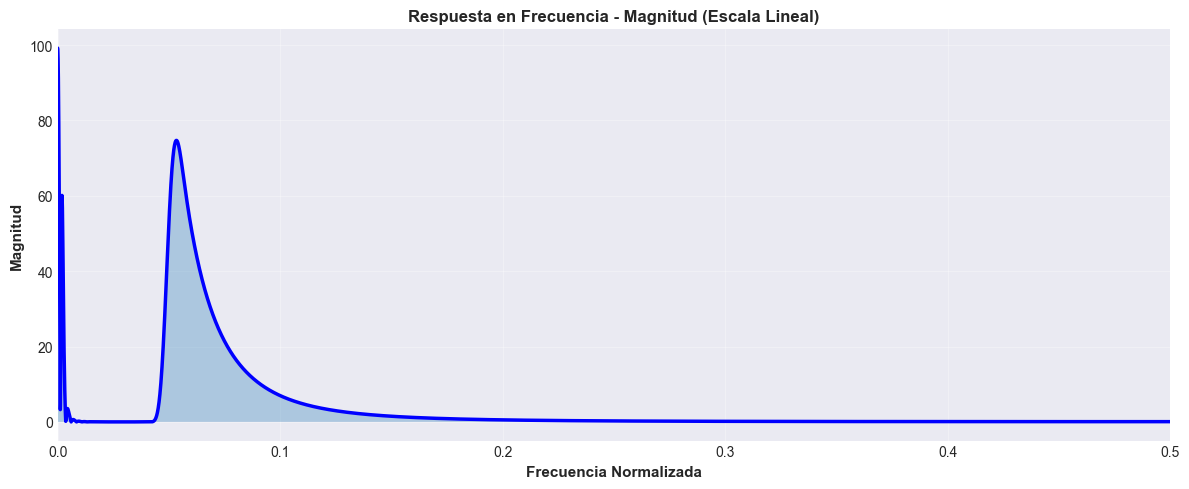

In [91]:
w, H = signal.freqz(h, a, worN=8000)
magnitude = np.abs(H)
fs = 1
f = w * fs / (2 * np.pi)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(f, magnitude, 'b', linewidth=2.5)
ax.fill_between(f, 0, magnitude, alpha=0.3)
ax.set_xlabel('Frecuencia Normalizada', fontsize=11, fontweight='bold')
ax.set_ylabel('Magnitud', fontsize=11, fontweight='bold')
ax.set_title('Respuesta en Frecuencia - Magnitud (Escala Lineal)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

## 10. Información Detallada de Ceros

In [92]:
print("\n" + "="*70)
print("INFORMACIÓN DETALLADA DE CEROS")
print("="*70)

for i, zero in enumerate(zeros):
    magnitude = np.abs(zero)
    phase = np.angle(zero, deg=True)
    real = zero.real
    imag = zero.imag
    
    estabilidad = "✓ Dentro" if magnitude < 1 else "● En" if magnitude == 1 else "✗ Fuera"
    
    print(f"\nCero #{i+1}:")
    print(f"  Valor: {real:>10.6f} + {imag:>10.6f}j")
    print(f"  Magnitud |z|: {magnitude:>10.6f}  {estabilidad} del círculo unitario")
    print(f"  Fase ∠z: {phase:>10.2f}°")

print("\n" + "="*70)


INFORMACIÓN DETALLADA DE CEROS

Cero #1:
  Valor:   1.000219 +   0.000000j
  Magnitud |z|:   1.000219  ✗ Fuera del círculo unitario
  Fase ∠z:       0.00°

Cero #2:
  Valor:   1.000000 +   0.000219j
  Magnitud |z|:   1.000000  ✗ Fuera del círculo unitario
  Fase ∠z:       0.01°

Cero #3:
  Valor:   1.000000 +  -0.000219j
  Magnitud |z|:   1.000000  ✗ Fuera del círculo unitario
  Fase ∠z:      -0.01°

Cero #4:
  Valor:   0.999781 +   0.000000j
  Magnitud |z|:   0.999781  ✓ Dentro del círculo unitario
  Fase ∠z:       0.00°



In [93]:
## 11. Exportar Coeficientes del Filtro para Arduino


In [94]:
# Extraer coeficientes del filtro Butterworth IIR para Arduino
# El filtro SOS (Second-Order Sections) contiene múltiples secciones
# Cada sección es: [b0, b1, b2, a0, a1, a2]

print("\n" + "="*70)
print("COEFICIENTES DEL FILTRO BUTTERWORTH IIR PARA ARDUINO")
print("="*70)

print(f"\nFiltro IIR Butterworth Paso Alto")
print(f"  Orden: 4")
print(f"  Frecuencia de corte: 0.5 Hz")
print(f"  Frecuencia de muestreo: 250 Hz")
print(f"  Formato: Second-Order Sections (SOS)")

print(f"\n# Estructura SOS completa:")
print(f"# Forma general: y[n] = (b0*x[n] + b1*x[n-1] + b2*x[n-2]) - (a1*y[n-1] + a2*y[n-2])")
print(f"# Nota: a0 siempre = 1 en forma normalizada\n")

# Normalizar los coeficientes SOS
sos_normalized = sos.copy()
for i in range(len(sos_normalized)):
    # Normalizar por a0 para evitar división en Arduino
    a0 = sos_normalized[i, 3]
    sos_normalized[i] = sos_normalized[i] / a0

print("Secciones de segundo orden normalizadas:\n")
for i, section in enumerate(sos_normalized):
    print(f"Sección {i+1}:")
    print(f"  b = [{section[0]:+.10f}, {section[1]:+.10f}, {section[2]:+.10f}]")
    print(f"  a = [1.0, {section[4]:+.10f}, {section[5]:+.10f}]")

# Convertir a formato Arduino con punto fijo (Q15 - 16 bits con 15 bits de precisión)
Q_BITS = 15  # Número de bits de precisión
SCALE = 2**Q_BITS

print(f"\n\nCÓDIGO ARDUINO (Q{Q_BITS} Fixed-Point):\n")
print("// ===== COEFICIENTES DEL FILTRO BUTTERWORTH IIR (Orden 4, 0.5 Hz) =====")
print("// Formato: Q15 fixed-point (16 bits con 15 bits de precisión)")
print("// Para usar: int32_t result = (coeff * sample) >> 15;\n")

# Crear array con todos los coeficientes
coeff_names = ['b0', 'b1', 'b2', 'a1', 'a2']
coeff_index = 0
all_coeffs = []

print("// SECCIÓN 1 (2do orden)")
for i in range(3):
    val = int(round(sos_normalized[0, i] * SCALE))
    all_coeffs.append((f"b0_s1" if i==0 else f"b1_s1" if i==1 else "b2_s1", val, sos_normalized[0, i]))

for i in range(2):
    val = int(round(sos_normalized[0, 4+i] * SCALE))
    all_coeffs.append((f"a1_s1" if i==0 else "a2_s1", val, sos_normalized[0, 4+i]))

print("int16_t b0_s1 = {:6d};  // {:.10f}".format(int(round(sos_normalized[0, 0] * SCALE)), sos_normalized[0, 0]))
print("int16_t b1_s1 = {:6d};  // {:.10f}".format(int(round(sos_normalized[0, 1] * SCALE)), sos_normalized[0, 1]))
print("int16_t b2_s1 = {:6d};  // {:.10f}".format(int(round(sos_normalized[0, 2] * SCALE)), sos_normalized[0, 2]))
print("int16_t a1_s1 = {:6d};  // {:.10f}".format(int(round(sos_normalized[0, 4] * SCALE)), sos_normalized[0, 4]))
print("int16_t a2_s1 = {:6d};  // {:.10f}".format(int(round(sos_normalized[0, 5] * SCALE)), sos_normalized[0, 5]))

print("\n// SECCIÓN 2 (2do orden)")
print("int16_t b0_s2 = {:6d};  // {:.10f}".format(int(round(sos_normalized[1, 0] * SCALE)), sos_normalized[1, 0]))
print("int16_t b1_s2 = {:6d};  // {:.10f}".format(int(round(sos_normalized[1, 1] * SCALE)), sos_normalized[1, 1]))
print("int16_t b2_s2 = {:6d};  // {:.10f}".format(int(round(sos_normalized[1, 2] * SCALE)), sos_normalized[1, 2]))
print("int16_t a1_s2 = {:6d};  // {:.10f}".format(int(round(sos_normalized[1, 4] * SCALE)), sos_normalized[1, 4]))
print("int16_t a2_s2 = {:6d};  // {:.10f}".format(int(round(sos_normalized[1, 5] * SCALE)), sos_normalized[1, 5]))

# Variable aracionales globales para almacenar estados previos
print("\n\n// Variables globales para almacenar estados previos del filtro IIR")
print("int32_t x1_s1 = 0, x2_s1 = 0;  // Estados de entrada sección 1")
print("int32_t y1_s1 = 0, y2_s1 = 0;  // Estados de salida sección 1")
print("int32_t x1_s2 = 0, x2_s2 = 0;  // Estados de entrada sección 2")
print("int32_t y1_s2 = 0, y2_s2 = 0;  // Estados de salida sección 2")

print("\n\n// Función de filtrado IIR con punto fijo")
print("""
int32_t applyIIRFilter(int32_t input) {
  int32_t out_s1, out_s2;
  
  // SECCIÓN 1: Aplicar ecuación de diferencias
  // y[n] = (b0*x[n] + b1*x[n-1] + b2*x[n-2]) - (a1*y[n-1] + a2*y[n-2])
  out_s1 = ((b0_s1 * input) >> 15);
  out_s1 += ((b1_s1 * x1_s1) >> 15);
  out_s1 += ((b2_s1 * x2_s1) >> 15);
  out_s1 -= ((a1_s1 * y1_s1) >> 15);
  out_s1 -= ((a2_s1 * y2_s1) >> 15);
  
  // Actualizar estado de la sección 1
  x2_s1 = x1_s1;
  x1_s1 = input;
  y2_s1 = y1_s1;
  y1_s1 = out_s1;
  
  // SECCIÓN 2: Aplicar ecuación de diferencias
  out_s2 = ((b0_s2 * out_s1) >> 15);
  out_s2 += ((b1_s2 * x1_s2) >> 15);
  out_s2 += ((b2_s2 * x2_s2) >> 15);
  out_s2 -= ((a1_s2 * y1_s2) >> 15);
  out_s2 -= ((a2_s2 * y2_s2) >> 15);
  
  // Actualizar estado de la sección 2
  x2_s2 = x1_s2;
  x1_s2 = out_s1;
  y2_s2 = y1_s2;
  y1_s2 = out_s2;
  
  return out_s2;
}
""")

print("\n✓ Coeficientes listos para copiar a Arduino")



COEFICIENTES DEL FILTRO BUTTERWORTH IIR PARA ARDUINO

Filtro IIR Butterworth Paso Alto
  Orden: 4
  Frecuencia de corte: 0.5 Hz
  Frecuencia de muestreo: 250 Hz
  Formato: Second-Order Sections (SOS)

# Estructura SOS completa:
# Forma general: y[n] = (b0*x[n] + b1*x[n-1] + b2*x[n-2]) - (a1*y[n-1] + a2*y[n-2])
# Nota: a0 siempre = 1 en forma normalizada

Secciones de segundo orden normalizadas:

Sección 1:
  b = [+0.9837151741, -1.9674303483, +0.9837151741]
  a = [1.0, -1.9768913543, +0.9770474536]
Sección 2:
  b = [+1.0000000000, -2.0000000000, +1.0000000000]
  a = [1.0, -1.9902712417, +0.9904283975]


CÓDIGO ARDUINO (Q15 Fixed-Point):

// ===== COEFICIENTES DEL FILTRO BUTTERWORTH IIR (Orden 4, 0.5 Hz) =====
// Formato: Q15 fixed-point (16 bits con 15 bits de precisión)
// Para usar: int32_t result = (coeff * sample) >> 15;

// SECCIÓN 1 (2do orden)
int16_t b0_s1 =  32234;  // 0.9837151741
int16_t b1_s1 = -64469;  // -1.9674303483
int16_t b2_s1 =  32234;  // 0.9837151741
int16_t a1_s